In [3]:
# Customer Segmentation Analysis

## OASIS INFOBYTE — Data Analytics Internship

### Task 2: Customer Segmentation Analysis

#**Objective:**  
#Segment customers based on their purchasing behaviour using RFM analysis and K-Means clustering.

#**Tools Used:**
#- Python
#- Pandas
#- Scikit-learn
# Matplotlib
#- Seaborn
#- Jupyter Notebook

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [6]:
print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
import os

print(os.getcwd())

C:\Users\polua


In [8]:
print(os.listdir())

['.....py', '.anaconda', '.antigravity', '.bash_history', '.conda', '.continuum', '.copilot', '.gemini', '.git', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.ms-ad', '.popsql.json', '.vscode', '.vscode-shared', 'anaconda', 'AntiGravity', 'AppData', 'Application Data', 'battery-report.html', 'Contacts', 'Cookies', 'CrossDevice', 'customer_segmentation.ipynb.ipynb', 'Customer_Segmentation_Analysis.ipynb.ipynb', 'Desktop', 'Downloads', 'Favorites', 'hotstarpdf', 'IMG_20260605_230903.jpg', 'Links', 'Local Settings', 'Mastering Control Flow – Conditionals & Loops in Python.ipynb', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{dfe5b72c-2028-11f0-8628-d05f7b19c90e}.TM.blf', 'NTUSER.DAT{dfe5b72c-2028-11f0-8628-d05f7b19c90e}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{dfe5b72c-2028-11f0-8628-d05f7b19c90e}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHoo

In [12]:
#load the dataset 
df = pd.read_excel(r"D:\ashok\OneDrive\Data Analyst\online+retail\Online Retail.xlsx")

In [13]:
#to display the first 5 rows 
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [14]:
#Check teh data size
df.shape

(541909, 8)

In [15]:
#Check the column names and data types
df.info


<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Cust

In [18]:
#Checking the missing null values 
df.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [20]:
#Checked the duplicate row 
df.duplicated().sum()


np.int64(5268)

In [22]:
df[df.duplicated()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [25]:
#check teh important numeric columns
df[['Quantity', 'UnitPrice',]].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [28]:
#Check the cancelled invoices 
df['InvoiceNo'].astype(str).str.startswith('C').sum()


np.int64(9288)

In [32]:
#Remove the duplicates 
df=df.drop_duplicates()

In [33]:
#Remove rows without CustomerID
df = df.dropna(subset=['CustomerID'])

In [35]:
#Remove cancelled transactions
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [36]:
#Remove invalid quantities
df = df[df['Quantity'] > 0]

In [37]:
#Remove invalid prices
df = df[df['UnitPrice'] > 0]

In [38]:
#Check the cleaned dataset 
df.shape

(392692, 8)

In [39]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


In [42]:
#Prepare the transaction date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [43]:
#Calculate total amount for each transaction
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [44]:
#Choose the analysis date
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [46]:
#Create the RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

In [47]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [49]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [51]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [53]:
rfm.shape

(4338, 3)

In [54]:
#Check your RFM data
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [56]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [57]:
rfm.shape

(4338, 3)

In [58]:
#Standardize the RFM values
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


In [61]:
#Check the scaled data
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.801745e-17,2.293130e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-4.250965e-01,-2.276151e-01
25%,-7.453445e-01,-4.250965e-01,-1.939190e-01
50%,-4.153533e-01,-2.951776e-01,-1.536162e-01
75%,4.946227e-01,9.457903e-02,-4.319704e-02
max,2.814561e+00,2.659803e+01,3.096074e+01


In [62]:
#Elbow Method
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

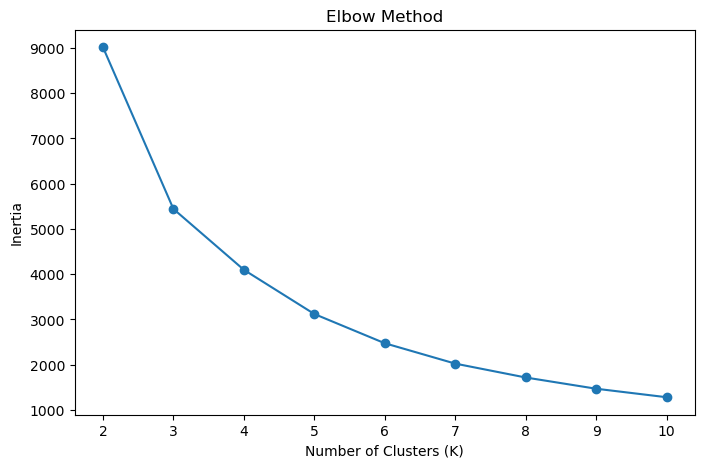

In [63]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [64]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [65]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [66]:
#Calculate the average RFM values for each cluster
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.918635,3.650262,1333.132908
1,248.469426,1.553151,478.648242
2,6.500000,120.500000,55099.491250
3,15.671362,21.286385,12813.941596
4,7.666667,42.833333,190808.536667


In [67]:
#heck how many customers are in each cluster
rfm['Cluster'].value_counts().sort_index()

Cluster
0    3048
1    1063
2       8
3     213
4       6
Name: count, dtype: int64

In [68]:
#Display both together
cluster_summary['CustomerCount'] = rfm['Cluster'].value_counts().sort_index()

cluster_summary

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,43.918635,3.650262,1333.132908,3048
1,248.469426,1.553151,478.648242,1063
2,6.500000,120.500000,55099.491250,8
3,15.671362,21.286385,12813.941596,213
4,7.666667,42.833333,190808.536667,6


In [69]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.918635,3.650262,1333.132908
1,248.469426,1.553151,478.648242
2,6.500000,120.500000,55099.491250
3,15.671362,21.286385,12813.941596
4,7.666667,42.833333,190808.536667


In [70]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0    3048
1    1063
2       8
3     213
4       6
Name: count, dtype: int64

In [71]:
cluster_summary['CustomerCount'] = rfm['Cluster'].value_counts().sort_index()
cluster_summary

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,43.918635,3.650262,1333.132908,3048
1,248.469426,1.553151,478.648242,1063
2,6.500000,120.500000,55099.491250,8
3,15.671362,21.286385,12813.941596,213
4,7.666667,42.833333,190808.536667,6


In [72]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_summary['CustomerCount'] = rfm['Cluster'].value_counts().sort_index()
cluster_summary

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,43.918635,3.650262,1333.132908,3048
1,248.469426,1.553151,478.648242,1063
2,6.500000,120.500000,55099.491250,8
3,15.671362,21.286385,12813.941596,213
4,7.666667,42.833333,190808.536667,6


In [76]:
cluster_summary

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,43.918635,3.650262,1333.132908,3048
1,248.469426,1.553151,478.648242,1063
2,6.500000,120.500000,55099.491250,8
3,15.671362,21.286385,12813.941596,213
4,7.666667,42.833333,190808.536667,6


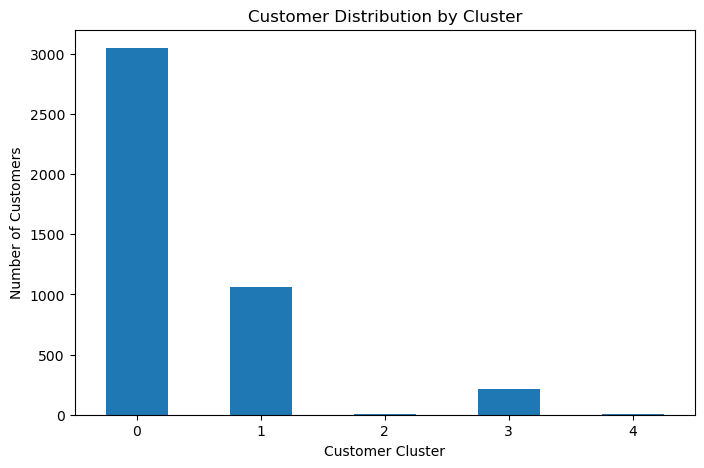

In [93]:
plt.figure(figsize=(8, 5))

rfm['Cluster'].value_counts().sort_index().plot(kind='bar')

plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by Cluster')
plt.xticks(rotation=0)

plt.show()

In [78]:
#RFM comparison table
cluster_summary

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,43.918635,3.650262,1333.132908,3048
1,248.469426,1.553151,478.648242,1063
2,6.500000,120.500000,55099.491250,8
3,15.671362,21.286385,12813.941596,213
4,7.666667,42.833333,190808.536667,6


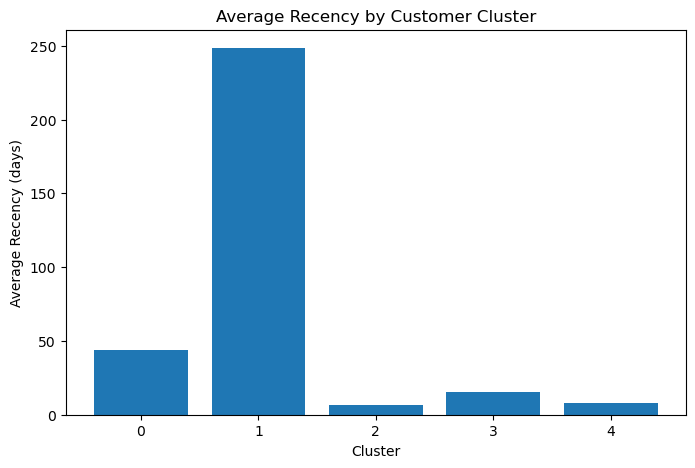

In [79]:
#Recency by cluster
plt.figure(figsize=(8, 5))
plt.bar(cluster_summary.index, cluster_summary['Recency'])
plt.xlabel('Cluster')
plt.ylabel('Average Recency (days)')
plt.title('Average Recency by Customer Cluster')
plt.show()

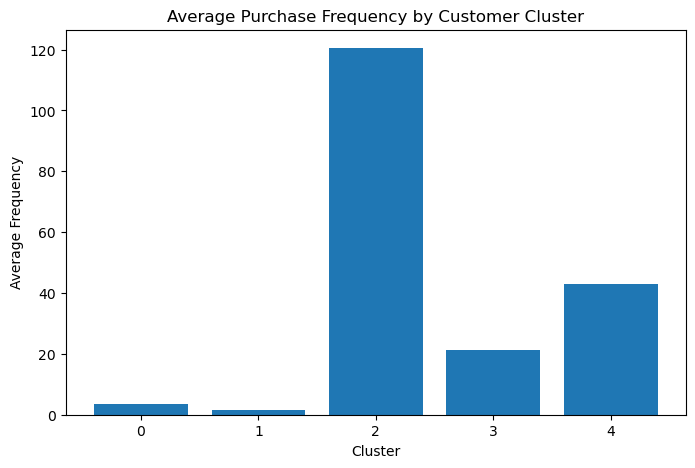

In [80]:
#Frequency by cluster
plt.figure(figsize=(8, 5))
plt.bar(cluster_summary.index, cluster_summary['Frequency'])
plt.xlabel('Cluster')
plt.ylabel('Average Frequency')
plt.title('Average Purchase Frequency by Customer Cluster')
plt.show()

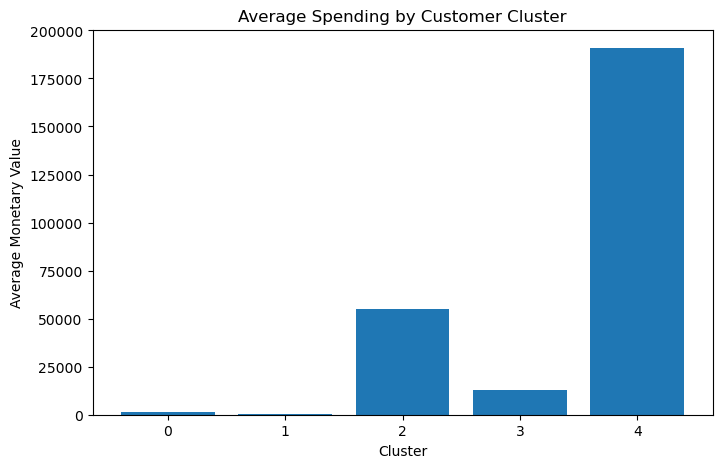

In [81]:
#Monetary by cluster
plt.figure(figsize=(8, 5))
plt.bar(cluster_summary.index, cluster_summary['Monetary'])
plt.xlabel('Cluster')
plt.ylabel('Average Monetary Value')
plt.title('Average Spending by Customer Cluster')
plt.show()

In [82]:
cluster_names = {
    0: 'Regular / Low-Value Customers',
    1: 'At-Risk / Inactive Customers',
    2: 'High-Value Loyal Customers',
    3: 'Loyal / High-Value Customers',
    4: 'VIP Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

In [83]:
#Check the result
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Loyal / High-Value Customers
12347.0,2,7,4310.00,0,Regular / Low-Value Customers
12348.0,75,4,1797.24,0,Regular / Low-Value Customers
12349.0,19,1,1757.55,0,Regular / Low-Value Customers
12350.0,310,1,334.40,1,At-Risk / Inactive Customers


In [84]:
#Check the segment counts
rfm['Segment'].value_counts()

Segment
Regular / Low-Value Customers    3048
At-Risk / Inactive Customers     1063
Loyal / High-Value Customers      213
High-Value Loyal Customers          8
VIP Customers                       6
Name: count, dtype: int64

In [85]:
#business recommendations table
recommendations = {
    'Regular / Low-Value Customers': 'Offer personalized discounts and product recommendations to increase purchase frequency and spending.',
    'At-Risk / Inactive Customers': 'Use re-engagement emails, special offers, and reminders to encourage them to return.',
    'High-Value Loyal Customers': 'Provide loyalty rewards and exclusive offers to retain these valuable customers.',
    'Loyal / High-Value Customers': 'Encourage repeat purchases through loyalty programs and personalized promotions.',
    'VIP Customers': 'Give premium treatment, exclusive products, and personalized services to retain these extremely valuable customers.'
}

for segment, recommendation in recommendations.items():
    print(segment, ":", recommendation)

Regular / Low-Value Customers : Offer personalized discounts and product recommendations to increase purchase frequency and spending.
At-Risk / Inactive Customers : Use re-engagement emails, special offers, and reminders to encourage them to return.
High-Value Loyal Customers : Provide loyalty rewards and exclusive offers to retain these valuable customers.
Loyal / High-Value Customers : Encourage repeat purchases through loyalty programs and personalized promotions.
VIP Customers : Give premium treatment, exclusive products, and personalized services to retain these extremely valuable customers.


In [86]:
#Creating a final summary table
final_summary = cluster_summary.copy()

final_summary['Segment'] = [
    'Regular / Low-Value Customers',
    'At-Risk / Inactive Customers',
    'High-Value Loyal Customers',
    'Loyal / High-Value Customers',
    'VIP Customers'
]

final_summary

,Recency,Frequency,Monetary,CustomerCount,Segment
Cluster,,,,,
0,43.918635,3.650262,1333.132908,3048,Regular / Low-Value Customers
1,248.469426,1.553151,478.648242,1063,At-Risk / Inactive Customers
2,6.500000,120.500000,55099.491250,8,High-Value Loyal Customers
3,15.671362,21.286385,12813.941596,213,Loyal / High-Value Customers
4,7.666667,42.833333,190808.536667,6,VIP Customers


In [88]:
#Save the final customer segmentation
rfm.to_csv('customer_segments.csv')

In [89]:
rfm.to_csv(r"D:\ashok\OneDrive\Data Analyst\online+retail\customer_segments.csv", index=True)

In [90]:
import os

os.path.exists(r"D:\ashok\OneDrive\Data Analyst\online+retail\customer_segments.csv")

True

In [91]:
os.path.abspath(r"D:\ashok\OneDrive\Data Analyst\online+retail\customer_segments.csv")

'D:\\ashok\\OneDrive\\Data Analyst\\online+retail\\customer_segments.csv'

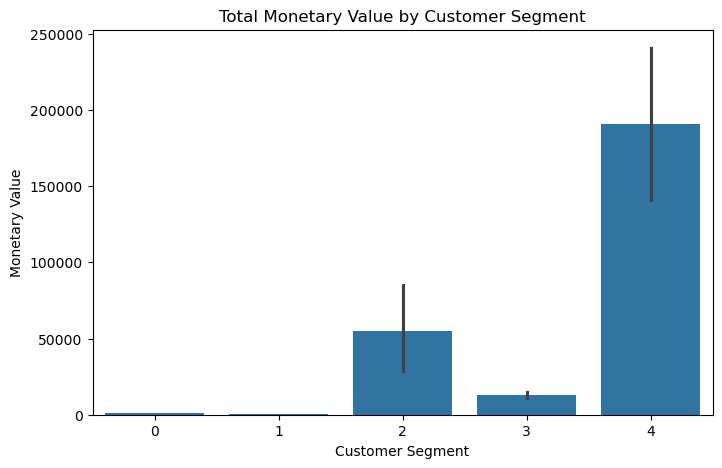

In [94]:
plt.figure(figsize=(8,5))
sns.barplot(data=rfm, x="Cluster", y="Monetary")
plt.title("Total Monetary Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Monetary Value")
plt.show()

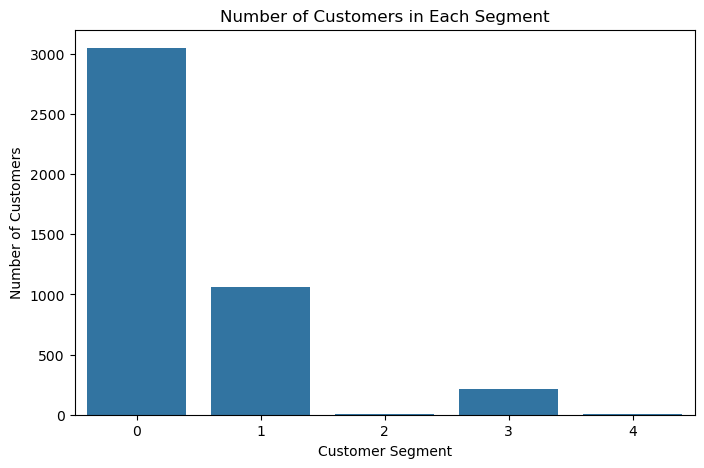

In [95]:
plt.figure(figsize=(8,5))
sns.countplot(data=rfm, x="Cluster")
plt.title("Number of Customers in Each Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.show()

In [96]:
rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,43.918635,3.650262,1333.132908
1,248.469426,1.553151,478.648242
2,6.500000,120.500000,55099.491250
3,15.671362,21.286385,12813.941596
4,7.666667,42.833333,190808.536667


In [97]:
import os
print(os.getcwd())

C:\Users\polua
